In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import sys
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import zscore, variation
from sklearn.preprocessing import normalize, scale, MinMaxScaler
import seaborn as sns

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
def accessData(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=False,  header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1

    return dic_dataframes

def accessData2(list_files, path, list_labels):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=0,  header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    
    return dic_dataframes

def accessData3(list_files, path, list_labels):
    """opens the read/transcript/gene counts of each file"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    
    return dic_dataframes


def accessData4(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,4,5,6,7,8,9],  header=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    return dic_dataframes

def accessData5(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=False,  header=0)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1

    return dic_dataframes

def saveCSV(dic_data, path, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(path+key+label+'.bed', sep='\t', header=False)

    return print('Files saved')

def saveCSV2(dic_data, path, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(path+key+label+'.bed', sep='\t', header=True)

    return print('Files saved')


def normalize(dic_data, dic_total, dic_scaling_value):
    """Normalize to desired value (mean, median...)
    1. divide by the total counts in each column
    2. multiply by scaling value"""
    #make a counter for the smaple number to select the scaling_value position
    count = 0
    #make a dictionary to store the normalized datasets
    dic_normal = {}
    #Get each dataframe
    for key in dic_data:
        #divide each section by the total of the section
        data_frame_normal_s1 = dic_data[key].divide(dic_total[key], axis='columns')
        #multiply by the scaling value
        data_frame_normal = data_frame_normal_s1.multiply(dic_scaling_value[key])
        count = count + 1
        #save the dataframe to the dictionary
        dic_normal[key] = data_frame_normal

    return dic_normal

def zscores(dic_data):
    """Calculates de z scores for each gene individually"""
    #Create a dictinary to store the dataframes of z scores
    dic_zscores = {}
    for key in dic_data:
        #create a dataframe to store the zscores
        df_zscore = pd.DataFrame(columns = dic_data[key].columns, index = dic_data[key].index)
        #calculate z scores for each gene
        #for that we need to get the info from every row independently and then get the z score
        for index in dic_data[key].index.values:
            #transform the series into list, then to np.array and apply z score funtion from scipy.stats
            #and save it to the Zscore df
            data_gene = np.array(list(dic_data[key].loc[index]))
            df_zscore.loc[index] = zscore(data_gene.astype(float))
        #save the df_zscores to the dictionary
        dic_zscores[key] = df_zscore.astype(float)
    
    return dic_zscores


def scaledZscores(dic_data):
    """Calculates de scaled z scores for each gene individually.
    Normalize the Z score to scaled Z score (-1 to 1)"""
    #Create a dictinary to store the dataframes of z scores
    dic_scaled_zscores = {}
    for key in dic_data:
        #create a dataframe to store the zscores
        df_scaled_zscore = pd.DataFrame(columns = dic_data[key].columns, index = dic_data[key].index)
        #calculate z scores for each gene
        #for that we need to get the info from every row independently and then get the z score
        for index in dic_data[key].index.values:
            ## 1.convert the column value of the dataframe to floats
            float_array = dic_data[key].loc[index].values.astype(float)
            # Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.
            float_array = float_array.reshape(-1, 1)
            # 2. create a min max processing object
            min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
            scaled_array = min_max_scaler.fit_transform(float_array)
            # 3. convert the scaled array to dataframe. First reshape the array to the original shape
            scaled_array = scaled_array.reshape(len(dic_data[key].columns.values),)
            df_scaled_zscore.loc[index] = scaled_array
        #save the df_zscores to the dictionary 
        #Use astype(float) to ensure the values are numbers for correct plotting
        dic_scaled_zscores[key] = df_scaled_zscore.astype(float)
    
    return dic_scaled_zscores


def meanDataset(dic_data):
    """Sum the different datasets and calculate the mean to create a Mean dataset"""
    #get a list of the keys
    keys = []
    for key in dic_data:
        keys.append(key)
    #create a new dataframe
    mean_dataset = pd.DataFrame(index = dic_data[keys[0]].index.values, columns = dic_data[keys[0]].index.values)
    for element in range(len(keys)):
        #add each dataframe individually
        #first combine the first two dataframes
        if element == 0:
            mean_dataset = dic_data[keys[0]].add(dic_data[keys[1]], axis='index')
        #add the remaining dataframes to the existent sum
        if element > 1:
            mean_dataset = mean_dataset.add(dic_data[keys[element]], axis='index')
    #divide by the number of samples to make the mean
    mean_dataset = mean_dataset.div(len(keys))
    
    #re-normalize z-scores
    #create dic_data 
    dic_data = {'mean': mean_dataset}
    mean_dataset_scaled = scaledZscores(dic_data)
    
    return mean_dataset_scaled


## Anna's formulas for hierarchical clustering
def hierarchicalClustering(df, cth = 100, plot = False, method = 'ward', metric = 'euclidean', nolabels = 'True', leaf_colors = []):
    """performs hierarchical clustering using linkage and dendogram functions from scipy.cluster.hierarchy package"""
    if len(leaf_colors) > 0:
        hierarchy.set_link_color_palette(leaf_colors)
    Z = linkage(df, method=method, metric = metric)
    dg = dendrogram(Z, no_labels=nolabels, color_threshold=cth, no_plot = np.invert(plot))
    plt.show()
    return Z, dg

## Anna's formulas for hierarchical clustering
def hierarchicalClustering2(df, cth = 100, plot = False, method = 'average', metric = 'euclidean', nolabels = 'True', leaf_colors = []):
    """performs hierarchical clustering using linkage and dendogram functions from scipy.cluster.hierarchy package"""
    if len(leaf_colors) > 0:
        hierarchy.set_link_color_palette(leaf_colors)
    Z = linkage(df, method=method, metric = metric)
    dg = dendrogram(Z, no_labels=nolabels, color_threshold=cth, no_plot = np.invert(plot))
    plt.show()
    return Z, dg

def getClusterByColor(dg, labels):
    """given a dendogram and labels, it groups labels by colors in the dendogram (i.e. clusters)"""
    kk = []
    ii = 0
    cluster = 0
    color = dg['color_list'][0]
    clusters = {cluster: []}
    for i in range(len(dg['icoord'])):
        v = dg['icoord'][i]
        for j in [0,2]:
            vj = int(round((v[j]-5.)/10))
            if (v[j]-5.)/10 == vj and vj not in kk:
                kk.append(vj)
                if dg['color_list'][i] == color:
                    clusters[cluster].append(labels[dg['leaves'][vj]])
                else:
                    color = dg['color_list'][i]
                    cluster += 1
                    clusters[cluster] = [labels[dg['leaves'][vj]]]
    return clusters


def plotHeatmap(dic_data, dg, clusters, figsize, title, type_data, reorganize = False, new_index_order = []):
    """Use the combined clustering to plot the indivudal heatmaps for each sample"""
    #access each dictionary and count the number of samples
    keys = []
    for key in dic_data:
        keys.append(key)      
    #check the number of samples to provide the width ratios
    ratios = [0.5]
    for element in range(len(keys)):
        if element < len(keys)-1:
            ratios.append(3)
        if element == len(keys)-1:
            ratios.append(4)
    # plot multiple plots with plt.sublots. axs is a list of all the subplots. Plot as many plots as samples plus 
    # one for the cluster label
    fig, axs = plt.subplots(nrows = 1, ncols = len(keys)+1, sharey='row', gridspec_kw={'width_ratios': ratios}, figsize = figsize);
    #make a count to access the correct plot
    count = 0
    for key in dic_data:
        if reorganize == False:
            #use dg['leaves'] indexes to organize the data to plot
            data_plot = dic_data[key].loc[dic_data[key].index[dg['leaves']]]
        if reorganize == True:
            data_plot = dic_data[key].reindex(index = new_index_order)
        # to plot I use ax.imshow
        im = axs[count+1].imshow(data_plot, aspect='auto', interpolation='none')
        # add labels
        axs[count+1].set_title(key)
        #remove ticks on the y axis
        axs[count+1].tick_params(top=False, bottom=True, left=False, right=False)
        #add 1 to the count to go to next sample
        count = count + 1
        
    #create the colour bar and label it, we use the last image (im)
    #cax = divider.append_axes('left', size='5%', pad=0.05)
    cb = fig.colorbar(im, orientation='vertical', shrink = 0.3)
    cb.set_label(type_data)

    # Make a big plot in order to craete shared axis labels
    # add a big axes, hide frame
    fig.add_subplot(111, frameon=False)
    # hide tick and tick label of the big axes
    plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    plt.grid(False)
    plt.xlabel("Sections A-P")

    #Introduce the cluster bar
    #make the variable bottom to 0, which indicates were the cluster starts
    bottom = 0
    for cluster in clusters:
        if int(cluster) < len(clusters)-1: 
            #get the height of the cluster
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster labels
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')
            #add the length of the current cluster to the bottom variable for the next cluster start
            bottom = bottom + len(clusters[cluster])

        #I add -1 to the last bottom, otherwise the plot gets out of the grid
        if int(cluster) == len(clusters)-1:
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster label
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')

    #axs[0].set_ylim(0,bottom)  

    #remove ticks and plot frame from the cluster bar
    axs[0].tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    axs[0].axis('off')
    #add the figure title
    fig.suptitle(title, fontsize=13)
    plt.show()
    
    
def ClusterGeneNames(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        for element in data[start:end]:
            #split the index and save the gene id and new line
            info = element.split('_')
            f.write(str(info[1]) + '\n')
        start = start + len(clusters[key])
    #close the file when done
    f.close()
    
    return print(file_name)


def ClusterEnsambleID(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        for element in data[start:end]:
            #split the index and save the gene id and new line
            info = element.split('_')
            f.write(str(info[0]) + '\n')
        start = start + len(clusters[key])
    #close the file when done
    f.close()
    
    return print(file_name)


def ClusterIndexs(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #create new dictiornary
    idx_cluster={}
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        list_idx=[]
        for index in data[start:end]:
            f.write(str(index) + '\n')
            list_idx.append(str(index))
        start = start + len(clusters[key])
        idx_cluster[str(key)]=list_idx
    #close the file when done
    f.close()
    
    return idx_cluster, print(file_name)


def ClusterIndex(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    dic_data={}
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        list_index=[]
        for element in data[start:end]:
            f.write(element + '\n')
            list_index.append(element)
        start = start + len(clusters[key])
        dic_data[key]=list_index
    #close the file when done
    f.close()
    
    return print(file_name), dic_data


def plotMeanCluster(dic_data, list_clusters, xlabel = 'Sections A-P', ylabel = 'Scaled z-score'):
    """Plot the specified cluster data"""
    #get cluster data and plot
    for key in dic_data:
        data_frame = dic_data[key]
        #find the column values for the cluster of interest
        for cluster in list_clusters:
            cluster_data = data_frame.loc[str(cluster)]
            #plot the data
            cluster_data.plot(label = cluster+1);
        plt.xlabel(xlabel,fontsize=15);
        plt.ylabel(ylabel,fontsize=15);
        plt.legend(fontsize=15, frameon=False);
        plt.title(key,fontsize=15)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.show();
    
    return plt

In [3]:
path=''

### Merged CpG information

In [36]:
#select only DEG from dataset
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
file_names = ['shared_filtered_cpg_coverage_table_TSS3kb_merged_normalized_DEG.bed']
labels = ['shared_filtered_merged']


#use accessData() function to obtain a dictonary with each dataset with labels as key
data_normal = accessData3(file_names, path, labels)
data_normal['shared_filtered_merged']

,M1-10,M1-11,M1-12,M1-13,M1-24,M1-25,M1-27,M1-35,M1-36,M1-38,...,M3-3,M3-4,M3-17,M3-18,M3-19,M3-20,M3-33,M3-34,M3-35,M3-36
ENSMUSG00000042686_Jph1_ProteinCoding,0.000000,0.000000,8.331541,17.207892,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.700233,0.000000,0.000000,25.009867,13.282963,7.382919,14.828795,0.000000,0.000000,6.229835
ENSMUSG00000026155_Smap1_ProteinCoding,25.452612,0.000000,1.190220,7.647952,0.000000,6.709796,7.312910,12.880438,6.220368,10.928762,...,36.903182,14.003008,18.568803,24.083575,18.596148,15.688703,39.543453,22.273936,36.531576,45.685458
ENSMUSG00000026154_Sdhaf4_ProteinCoding,0.000000,1.594197,42.847926,2.867982,63.448533,1.677449,105.630916,13.953808,34.212025,43.715049,...,43.203725,14.936542,48.632579,34.272780,33.650172,26.763082,20.760313,33.895120,43.442955,32.187482
ENSMUSG00000061518_Cox5b_ProteinCoding,0.000000,0.000000,4.760881,13.383916,0.000000,8.387245,22.751274,4.293479,58.056770,13.660953,...,39.603415,49.477297,45.095664,38.904237,48.704197,40.606055,42.509212,24.210800,47.392315,51.915293
ENSMUSG00000058407_Txndc9_ProteinCoding,0.000000,12.753577,17.853303,11.471928,8.275896,0.000000,0.000000,4.293479,17.624377,0.000000,...,25.202173,27.072483,21.221489,9.262914,19.481679,21.225892,15.817381,36.800416,33.569556,58.145129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,156.631458,176.955887,457.044547,166.342952,61.609445,296.908477,243.763652,202.866894,198.015054,199.449912,...,0.000000,3.734136,6.189601,8.336622,0.000000,16.611568,0.000000,1.936864,10.860739,2.076612
ENSMUSG00000071708_Sms_ProteinCoding,203.620895,38.260732,314.218126,168.254940,196.782408,46.129848,234.825651,272.635932,285.100209,257.736644,...,4.500388,0.000000,8.842287,9.262914,4.427654,7.382919,8.897277,13.558048,3.949360,9.344753
ENSMUSG00000046873_Mbtps2_ProteinCoding,957.409784,848.112900,806.969278,494.248887,483.680124,738.916295,870.236238,663.342543,509.033464,693.065676,...,13.501164,43.876093,10.610745,12.968079,13.282963,8.305784,5.931518,11.621184,29.620197,12.459670
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,1425.346264,492.606929,507.033794,534.400634,274.943645,226.455618,413.585663,637.581668,379.442460,658.457929,...,30.602639,4.667669,1.768457,2.778874,12.397432,1.845730,9.885863,5.810592,6.911379,1.038306


#### logFC anterior-posterior vs center female sections

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [37]:
data_normal_AP = data_normal['shared_filtered_merged'][[ 
    'M2-36','M2-37', 'M2-38', 'M2-39',
    'M1-35', 'M1-36', 'M1-38']]
data_normal_AP


,M2-36,M2-37,M2-38,M2-39,M1-35,M1-36,M1-38
ENSMUSG00000042686_Jph1_ProteinCoding,11.256501,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000026155_Smap1_ProteinCoding,25.014446,6.044354,11.710330,0.000000,12.880438,6.220368,10.928762
ENSMUSG00000026154_Sdhaf4_ProteinCoding,5.002889,12.088709,34.066414,50.108007,13.953808,34.212025,43.715049
ENSMUSG00000061518_Cox5b_ProteinCoding,0.000000,23.170025,59.616225,0.000000,4.293479,58.056770,13.660953
ENSMUSG00000058407_Txndc9_ProteinCoding,16.259390,14.103494,25.549811,0.000000,4.293479,17.624377,0.000000
...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,177.602569,29.214379,57.487074,315.262876,202.866894,198.015054,199.449912
ENSMUSG00000071708_Sms_ProteinCoding,157.591012,104.768809,106.457545,231.749531,272.635932,285.100209,257.736644
ENSMUSG00000046873_Mbtps2_ProteinCoding,1050.606749,293.151186,345.987020,561.627242,663.342543,509.033464,693.065676
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,835.482510,164.204960,154.363440,411.303222,637.581668,379.442460,658.457929


In [38]:
data_normal_C = data_normal['shared_filtered_merged'][['M1-10', 'M1-11', 'M1-12', 'M1-13',
    'M2-8', 'M2-9', 'M2-10', 'M2-11', 
    'M2-22', 'M2-23', 'M2-24', 'M2-25']]
data_normal_C

,M1-10,M1-11,M1-12,M1-13,M2-8,M2-9,M2-10,M2-11,M2-22,M2-23,M2-24,M2-25
ENSMUSG00000042686_Jph1_ProteinCoding,0.000000,0.000000,8.331541,17.207892,0.000000,0.000000,0.000000,0.000000,5.023046,3.910849,0.000000,0.000000
ENSMUSG00000026155_Smap1_ProteinCoding,25.452612,0.000000,1.190220,7.647952,3.196273,24.626268,7.854340,13.843253,14.064530,12.710260,7.295855,4.579152
ENSMUSG00000026154_Sdhaf4_ProteinCoding,0.000000,1.594197,42.847926,2.867982,0.000000,18.715963,46.144245,0.000000,21.096795,32.264507,41.039183,26.559083
ENSMUSG00000061518_Cox5b_ProteinCoding,0.000000,0.000000,4.760881,13.383916,12.785091,11.820609,8.836132,0.000000,20.092185,52.796465,32.831346,41.212371
ENSMUSG00000058407_Txndc9_ProteinCoding,0.000000,12.753577,17.853303,11.471928,0.000000,9.850507,25.526603,39.222551,9.041483,10.754836,20.975582,15.569118
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,156.631458,176.955887,457.044547,166.342952,155.551938,148.742657,190.467733,155.736601,155.714438,76.261561,71.134584,74.182267
ENSMUSG00000071708_Sms_ProteinCoding,203.620895,38.260732,314.218126,168.254940,24.504757,157.608113,181.631601,531.811653,269.235286,151.545410,215.227715,74.182267
ENSMUSG00000046873_Mbtps2_ProteinCoding,957.409784,848.112900,806.969278,494.248887,959.947233,702.341156,422.170749,1112.074692,398.829882,400.862053,837.199332,281.159952
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,1425.346264,492.606929,507.033794,534.400634,592.375873,286.649756,502.677729,412.990394,399.834491,218.029848,315.545718,229.873446


In [39]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered_merged'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

,A-P,C
ENSMUSG00000042686_Jph1_ProteinCoding,1.608072,2.872777
ENSMUSG00000026155_Smap1_ProteinCoding,10.399814,10.205060
ENSMUSG00000026154_Sdhaf4_ProteinCoding,27.592414,19.427490
ENSMUSG00000061518_Cox5b_ProteinCoding,22.685350,16.543250
ENSMUSG00000058407_Txndc9_ProteinCoding,11.118650,14.418291
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,168.556966,165.397219
ENSMUSG00000071708_Sms_ProteinCoding,202.291383,194.175125
ENSMUSG00000046873_Mbtps2_ProteinCoding,588.116269,685.110492
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,462.976598,493.113740


In [40]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


ENSMUSG00000042686_Jph1_ProteinCoding      -0.837115
ENSMUSG00000026155_Smap1_ProteinCoding      0.027273
ENSMUSG00000026154_Sdhaf4_ProteinCoding     0.506172
ENSMUSG00000061518_Cox5b_ProteinCoding      0.455518
ENSMUSG00000058407_Txndc9_ProteinCoding    -0.374919
                                              ...   
ENSMUSG00000041115_Iqsec2_ProteinCoding     0.027301
ENSMUSG00000071708_Sms_ProteinCoding        0.059076
ENSMUSG00000046873_Mbtps2_ProteinCoding    -0.220235
ENSMUSG00000040990_Sh3kbp1_ProteinCoding   -0.090981
ENSMUSG00000049775_Tmsb4x_ProteinCoding    -0.020409
Length: 682, dtype: float64

In [41]:
list_idx=[index.split('_')[1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

,Gene,log2FC A-P vs C
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.837115
ENSMUSG00000026155_Smap1_ProteinCoding,Smap1,0.027273
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Sdhaf4,0.506172
ENSMUSG00000061518_Cox5b_ProteinCoding,Cox5b,0.455518
ENSMUSG00000058407_Txndc9_ProteinCoding,Txndc9,-0.374919
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Iqsec2,0.027301
ENSMUSG00000071708_Sms_ProteinCoding,Sms,0.059076
ENSMUSG00000046873_Mbtps2_ProteinCoding,Mbtps2,-0.220235
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Sh3kbp1,-0.090981


In [42]:
df = pd.read_excel("DEG.xlsx", header=0, index_col=0)
list1=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] >= 0.4)].index
list2=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] <= -0.4)].index
df_sig=df.loc[df_FC.index]
# Create a new column based on index membership
df_sig['Annotation'] = np.where(df_sig.index.isin(list1), 'Central', 
                    np.where(df_sig.index.isin(list2), 'Proximal-distal', np.nan))
# Check the result
list_ann=df_sig.drop(['Mean z-score difference', 'Proximal-distal_s', 'Central_s', 'p_value', 'adj_p_value'], axis=1)
list_ann

,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Proximal-distal
ENSMUSG00000026155_Smap1_ProteinCoding,Proximal-distal
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Central
ENSMUSG00000061518_Cox5b_ProteinCoding,Central
ENSMUSG00000058407_Txndc9_ProteinCoding,Proximal-distal
...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Central
ENSMUSG00000071708_Sms_ProteinCoding,Proximal-distal
ENSMUSG00000046873_Mbtps2_ProteinCoding,Proximal-distal
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Central


In [43]:
df_FC_ann=pd.concat([df_FC, list_ann], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
#df_FC_ann=df_FC_ann.sort_values('log2FC A-P vs C', ascending=False)
df_FC_ann.tail(20)

,Gene,log2FC A-P vs C,Annotation
ENSMUSG00000059734_Ndufs8_ProteinCoding,Ndufs8,0.251591,Central
ENSMUSG00000024646_Cyb5a_ProteinCoding,Cyb5a,0.185030,Central
ENSMUSG00000025428_Atp5a1_ProteinCoding,Atp5a1,0.137803,Central
ENSMUSG00000036880_Acaa2_ProteinCoding,Acaa2,-0.885878,Central
ENSMUSG00000053477_Tcf4_ProteinCoding,Tcf4,-0.197068,Central
ENSMUSG00000038121_Fam210a_ProteinCoding,Fam210a,-0.704829,Central
ENSMUSG00000032735_Ablim3_ProteinCoding,Ablim3,0.519529,Central
ENSMUSG00000019647_Sema6a_ProteinCoding,Sema6a,-0.055468,Central
ENSMUSG00000036585_Fgf1_ProteinCoding,Fgf1,-0.829538,Central
ENSMUSG00000024411_Aqp4_ProteinCoding,Aqp4,2.083786,Central


In [44]:
df_FC_ann=pd.concat([df_FC, list_ann], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

,Gene,log2FC A-P vs C,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.837115,Proximal-distal
ENSMUSG00000030401_Rtn2_ProteinCoding,Rtn2,-0.132792,Proximal-distal
ENSMUSG00000024091_Vapa_ProteinCoding,Vapa,-2.809986,Proximal-distal
ENSMUSG00000017831_Rab5a_ProteinCoding,Rab5a,-1.365168,Proximal-distal
ENSMUSG00000040694_Apobec2_ProteinCoding,Apobec2,0.938561,Proximal-distal
...,...,...,...
ENSMUSG00000002379_Ndufa11_ProteinCoding,Ndufa11,0.186937,Central
ENSMUSG00000023939_Mrpl14_ProteinCoding,Mrpl14,0.062230,Central
ENSMUSG00000039601_Rcan2_ProteinCoding,Rcan2,-3.124658,Central
ENSMUSG00000023921_Mmut_ProteinCoding,Mmut,-1.334556,Central


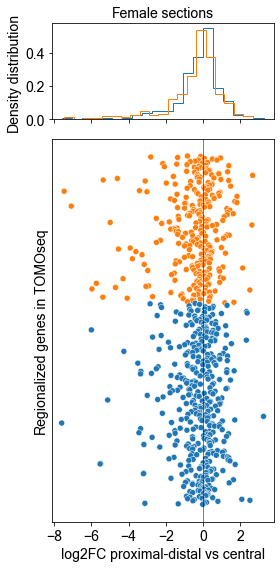

In [45]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Female sections", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False  # disables legend
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD all tss female.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

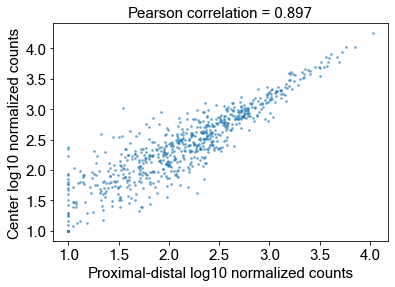

In [14]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

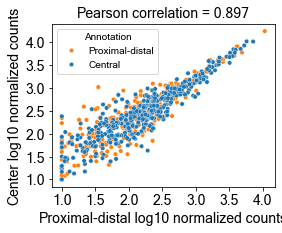

In [15]:
data_frame_ann=pd.concat([data_frame, list_ann], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=20)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD all tss female.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


#### logFC anterior-posterior vs center male sections

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [16]:
data_normal_AP = data_normal['shared_filtered_merged'][['M3-1', 'M3-2', 'M3-3', 'M3-4','M3-33', 'M3-34', 'M3-35', 'M3-36']]
data_normal_AP


,M3-1,M3-2,M3-3,M3-4,M3-33,M3-34,M3-35,M3-36
ENSMUSG00000042686_Jph1_ProteinCoding,0.000000,30.036040,2.700233,0.000000,14.828795,0.000000,0.000000,6.229835
ENSMUSG00000026155_Smap1_ProteinCoding,34.758896,109.543206,36.903182,14.003008,39.543453,22.273936,36.531576,45.685458
ENSMUSG00000026154_Sdhaf4_ProteinCoding,46.004422,2.650239,43.203725,14.936542,20.760313,33.895120,43.442955,32.187482
ENSMUSG00000061518_Cox5b_ProteinCoding,39.870499,71.556449,39.603415,49.477297,42.509212,24.210800,47.392315,51.915293
ENSMUSG00000058407_Txndc9_ProteinCoding,19.424089,0.000000,25.202173,27.072483,15.817381,36.800416,33.569556,58.145129
...,...,...,...,...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,0.000000,49.471125,0.000000,3.734136,0.000000,1.936864,10.860739,2.076612
ENSMUSG00000071708_Sms_ProteinCoding,5.111602,0.000000,4.500388,0.000000,8.897277,13.558048,3.949360,9.344753
ENSMUSG00000046873_Mbtps2_ProteinCoding,13.290166,1.766826,13.501164,43.876093,5.931518,11.621184,29.620197,12.459670
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,5.111602,21.201911,30.602639,4.667669,9.885863,5.810592,6.911379,1.038306


In [17]:
data_normal_C = data_normal['shared_filtered_merged'][['M3-17', 'M3-18','M3-19', 'M3-20']]
data_normal_C

,M3-17,M3-18,M3-19,M3-20
ENSMUSG00000042686_Jph1_ProteinCoding,0.000000,25.009867,13.282963,7.382919
ENSMUSG00000026155_Smap1_ProteinCoding,18.568803,24.083575,18.596148,15.688703
ENSMUSG00000026154_Sdhaf4_ProteinCoding,48.632579,34.272780,33.650172,26.763082
ENSMUSG00000061518_Cox5b_ProteinCoding,45.095664,38.904237,48.704197,40.606055
ENSMUSG00000058407_Txndc9_ProteinCoding,21.221489,9.262914,19.481679,21.225892
...,...,...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,6.189601,8.336622,0.000000,16.611568
ENSMUSG00000071708_Sms_ProteinCoding,8.842287,9.262914,4.427654,7.382919
ENSMUSG00000046873_Mbtps2_ProteinCoding,10.610745,12.968079,13.282963,8.305784
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,1.768457,2.778874,12.397432,1.845730


In [18]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered_merged'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

,A-P,C
ENSMUSG00000042686_Jph1_ProteinCoding,6.724363,11.418937
ENSMUSG00000026155_Smap1_ProteinCoding,42.405340,19.234307
ENSMUSG00000026154_Sdhaf4_ProteinCoding,29.635100,35.829653
ENSMUSG00000061518_Cox5b_ProteinCoding,45.816910,43.327538
ENSMUSG00000058407_Txndc9_ProteinCoding,27.003903,17.797993
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,8.509934,7.784448
ENSMUSG00000071708_Sms_ProteinCoding,5.670178,7.478944
ENSMUSG00000046873_Mbtps2_ProteinCoding,16.508352,11.291893
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,10.653745,4.697623


In [19]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


ENSMUSG00000042686_Jph1_ProteinCoding      -0.763959
ENSMUSG00000026155_Smap1_ProteinCoding      1.140564
ENSMUSG00000026154_Sdhaf4_ProteinCoding    -0.273847
ENSMUSG00000061518_Cox5b_ProteinCoding      0.080596
ENSMUSG00000058407_Txndc9_ProteinCoding     0.601453
                                              ...   
ENSMUSG00000041115_Iqsec2_ProteinCoding     0.128553
ENSMUSG00000071708_Sms_ProteinCoding       -0.399440
ENSMUSG00000046873_Mbtps2_ProteinCoding     0.547909
ENSMUSG00000040990_Sh3kbp1_ProteinCoding    1.181358
ENSMUSG00000049775_Tmsb4x_ProteinCoding     0.835415
Length: 682, dtype: float64

In [20]:
list_idx=[index.split('_')[1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

,Gene,log2FC A-P vs C
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.763959
ENSMUSG00000026155_Smap1_ProteinCoding,Smap1,1.140564
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Sdhaf4,-0.273847
ENSMUSG00000061518_Cox5b_ProteinCoding,Cox5b,0.080596
ENSMUSG00000058407_Txndc9_ProteinCoding,Txndc9,0.601453
...,...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Iqsec2,0.128553
ENSMUSG00000071708_Sms_ProteinCoding,Sms,-0.399440
ENSMUSG00000046873_Mbtps2_ProteinCoding,Mbtps2,0.547909
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Sh3kbp1,1.181358


In [21]:
df = pd.read_excel("DEG.xlsx", header=0, index_col=0)
list1=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] >= 0.4)].index
list2=df[(df['adj_p_value'] <= 0.05) & (df['Mean z-score difference'] <= -0.4)].index
df_sig=df.loc[df_FC.index]
# Create a new column based on index membership
df_sig['Annotation'] = np.where(df_sig.index.isin(list1), 'Central', 
                    np.where(df_sig.index.isin(list2), 'Proximal-distal', np.nan))
# Check the result
list_ann=df_sig.drop(['Mean z-score difference', 'Proximal-distal_s', 'Central_s', 'p_value', 'adj_p_value'], axis=1)
list_ann

,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Proximal-distal
ENSMUSG00000026155_Smap1_ProteinCoding,Proximal-distal
ENSMUSG00000026154_Sdhaf4_ProteinCoding,Central
ENSMUSG00000061518_Cox5b_ProteinCoding,Central
ENSMUSG00000058407_Txndc9_ProteinCoding,Proximal-distal
...,...
ENSMUSG00000041115_Iqsec2_ProteinCoding,Central
ENSMUSG00000071708_Sms_ProteinCoding,Proximal-distal
ENSMUSG00000046873_Mbtps2_ProteinCoding,Proximal-distal
ENSMUSG00000040990_Sh3kbp1_ProteinCoding,Central


In [22]:
df_FC_ann=pd.concat([df_FC, list_ann], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

,Gene,log2FC A-P vs C,Annotation
ENSMUSG00000042686_Jph1_ProteinCoding,Jph1,-0.763959,Proximal-distal
ENSMUSG00000030401_Rtn2_ProteinCoding,Rtn2,-0.278707,Proximal-distal
ENSMUSG00000024091_Vapa_ProteinCoding,Vapa,-0.136980,Proximal-distal
ENSMUSG00000017831_Rab5a_ProteinCoding,Rab5a,0.070965,Proximal-distal
ENSMUSG00000040694_Apobec2_ProteinCoding,Apobec2,-0.179187,Proximal-distal
...,...,...,...
ENSMUSG00000002379_Ndufa11_ProteinCoding,Ndufa11,-0.357033,Central
ENSMUSG00000023939_Mrpl14_ProteinCoding,Mrpl14,-0.225840,Central
ENSMUSG00000039601_Rcan2_ProteinCoding,Rcan2,-0.006446,Central
ENSMUSG00000023921_Mmut_ProteinCoding,Mmut,-0.764140,Central


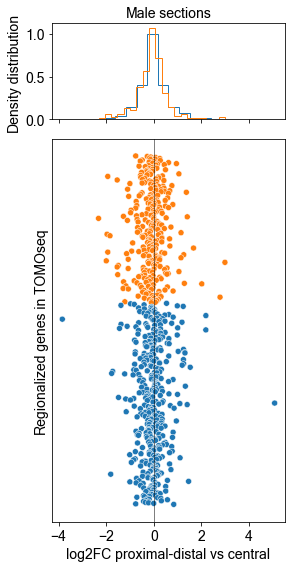

In [23]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Male sections", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False  # disables legend
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD all tss male.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

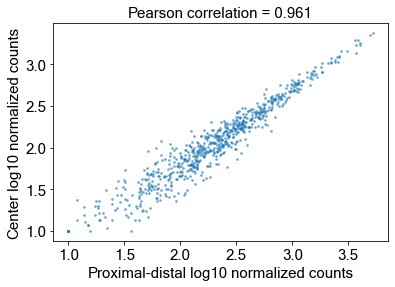

In [24]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

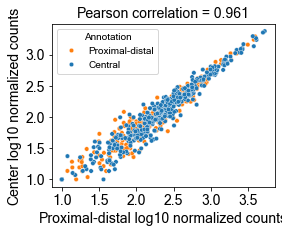

In [25]:
data_frame_ann=pd.concat([data_frame, list_ann], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=20)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD all tss male.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


### Unmerged CpG information

In [23]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
file_names = ['shared_filtered_cpg_coverage_table_TSS3kb_normalized_DEG.bed']
labels = ['shared_filtered']


#use accessData() function to obtain a dictonary with each dataset with labels as key
data_normal = accessData4(file_names, path, labels)
data_normal['shared_filtered']

/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_90850/1401350171.py:59: DtypeWarning: Columns (0,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,4,5,6,7,8,9],  header=0)


M1-10  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                  
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
...                                                                                                                     ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  297.599769   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   

                                                                                                                 M1-11  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                             
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
...                                                                                                                ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   

                                                                                                                     M1-12  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000 

#### Reproducibility 

In [24]:
data_total_norm={}
data_total_norm['Muscle_1']= data_normal['shared_filtered'].iloc[:,:10].sum(axis=1)
data_total_norm['Muscle_2']= data_normal['shared_filtered'].iloc[:,10:22].sum(axis=1)
data_total_norm['Muscle_3']= data_normal['shared_filtered'].iloc[:,22:].sum(axis=1)
data_total_norm

{'Muscle_1': chr  start      end        Lpnp1  Lpnp1_n   chr_g  start_g    end_g      strand  gene                                   
 1    17097791   17097792   CCG    44696     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
      17097794   17097795   CCG    44697     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
      17097817   17097818   CCG    44698     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
      17097820   17097821   CCG    44699     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
      17097825   17097826   CCGG   44700     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding         0.000000
                                                                                                                                ...     
 X    167211004  167211005  CCGG   10922891 

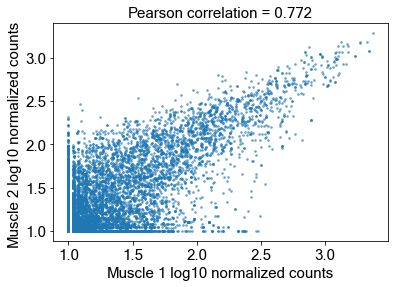

In [25]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_1'].index)
my_list1=list(data_total_norm['Muscle_1'])
data_frame['Muscle_1']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_2'])
data_frame['Muscle_2']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_1'], data_frame['Muscle_2'])

data_frame.plot(x='Muscle_1', y='Muscle_2', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 1 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 2 log10 normalized counts', fontsize=15)
plt.show()

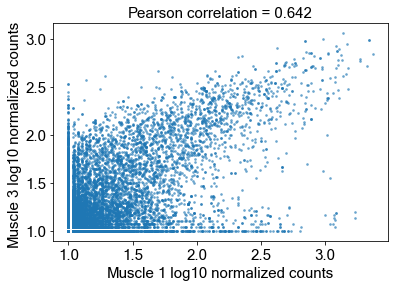

In [26]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_1'].index)
my_list1=list(data_total_norm['Muscle_1'])
data_frame['Muscle_1']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_3'])
data_frame['Muscle_3']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_1'], data_frame['Muscle_3'])

data_frame.plot(x='Muscle_1', y='Muscle_3', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 1 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 3 log10 normalized counts', fontsize=15)
plt.show()

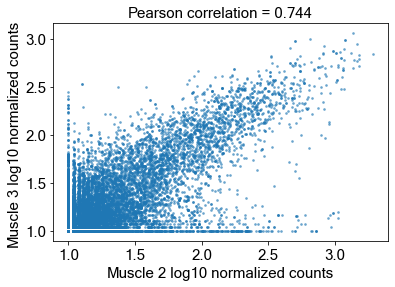

In [27]:
data_frame=pd.DataFrame(index=data_total_norm['Muscle_2'].index)
my_list1=list(data_total_norm['Muscle_2'])
data_frame['Muscle_2']=np.log10([x+10 for x in my_list1])
my_list2=list(data_total_norm['Muscle_3'])
data_frame['Muscle_3']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Muscle_2'], data_frame['Muscle_3'])

data_frame.plot(x='Muscle_2', y='Muscle_3', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Muscle 2 log10 normalized counts', fontsize=15)
plt.ylabel('Muscle 3 log10 normalized counts', fontsize=15)
plt.show()

#### logFC anterior-posterior vs center female

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [28]:
data_normal_AP = data_normal['shared_filtered'][[ 
    'M2-36','M2-37', 'M2-38', 'M2-39',
    'M1-35', 'M1-36', 'M1-38']]
data_normal_AP


M2-36  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  20.011557   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  37.521670   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   

                                                                                                                     M2-37  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   6.044354   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  33.243949   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  21.155240   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   3.022177   

                                                                                                                     M2-38  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG0000

In [29]:
data_normal_C = data_normal['shared_filtered'][['M1-10', 'M1-11', 'M1-12', 'M1-13',
    'M2-8', 'M2-9', 'M2-10', 'M2-11', 
    'M2-22', 'M2-23', 'M2-24', 'M2-25']]
data_normal_C

M1-10  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                  
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.000000   
...                                                                                                                     ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  297.599769   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.000000   

                                                                                                                 M1-11  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                             
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      0.0   
...                                                                                                                ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    0.0   

                                                                                                                     M1-12  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000 

In [30]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

A-P  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   3.967728   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  49.644118   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  25.006875   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   5.931826   

                                                                                                                         C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.081476  
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.081476  
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000  
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000  
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000  
...                                                                                                                    ...  
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   3.016212  
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  93.252093  
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  23.527575  
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   4.281672  
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   1.241093  

[26032 rows x 2 columns]

In [31]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


chr  start      end        Lpnp1  Lpnp1_n   chr_g  start_g    end_g      strand  gene                                   
1    17097791   17097792   CCG    44696     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -0.859779
     17097794   17097795   CCG    44697     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -0.859779
     17097817   17097818   CCG    44698     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
     17097820   17097821   CCG    44699     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
     17097825   17097826   CCGG   44700     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
                                                                                                                              ...   
X    167211004  167211005  CCGG   10922891  X      167209215  167212315  -       

In [32]:
list_idx=[index[-1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                               
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
...                                                                                                                                                  ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                 log2FC A-P vs C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                      
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -0.859779  
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -0.859779  
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
...                                                                                                                          ...  
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         0.395575  
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding        -0.909513  
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         0.087972  
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding        -5.453409  
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         2.256865  

[26032 rows x 2 columns]

In [33]:
list_ann2=pd.DataFrame(index=df_FC.index, columns=['Annotation'])
for index in df_FC.index:
    list_ann2.loc[index]['Annotation']=list_ann['Annotation'].loc[df_FC.loc[index]['Gene']]
#list_ann2["Annotation"] = list_ann2["Annotation"].str.replace("A-P", "PD", regex=False)
list_ann2

Annotation
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                    
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
...                                                                                                                          ...
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central

[26032 rows x 1 columns]

In [34]:
df_FC_ann=pd.concat([df_FC, list_ann2], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding        ENSMUSG00000042686_Jph1_ProteinCoding   
3   65393580  65393581  GCGC  1735809  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393324  65393325  CGG   1735797  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393350  65393351  CGG   1735798  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393360  65393361  GCGC  1735799  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
...                                                                                                                                                    ...   
11  107470666 107470667 CGG   6979886  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470657 107470658 CCG   6979885  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470643 107470644 GCGC  6979884  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470641 107470642 GCGC  6979883  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
X   167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                  log2FC A-P vs C  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                        
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding           -0.859779   
3   65393580  65393581  GCGC  1735809  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.000000   
    65393324  65393325  CGG   1735797  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            1.081321   
    65393350  65393351  CGG   1735798  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding           -1.368127   
    65393360  65393361  GCGC  1735799  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.000000   
...                                                                                                                           ...   
11  107470666 107470667 CGG   6979886  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         1.202288   
    107470657 107470658 CCG   6979885  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         0.000000   
    107470643 107470644 GCGC  6979884  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding        -0.994109   
    107470641 107470642 GCGC  6979883  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding        -0.994109   
X   167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          2.256865   

                                                                                                                       Annotation  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                       
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_Prote

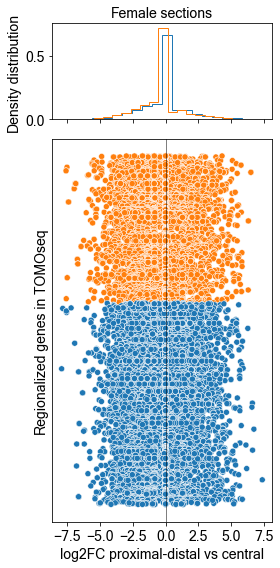

In [35]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Female sections", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False,  # disables legend
    rasterized=True
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD individual tss female.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

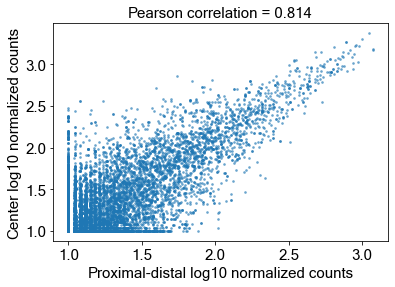

In [40]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

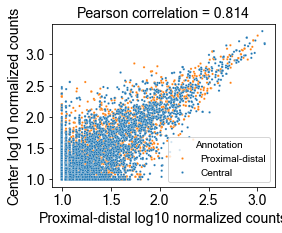

In [41]:
data_frame_ann=pd.concat([data_frame, list_ann2], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=5, rasterized=True)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD indivual tss female.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


#### logFC anterior-posterior vs center male

Muscle 1: first 4 sections center, midle 4 sections inbetween, last 4 sections AP

Muscle 2: first 4 and midle 4 sections center, last 4 sections AP

Muscle 3: fisrt 4 sections AP, midle 4 sections center, last 4 sections AP

In [36]:
data_normal_AP = data_normal['shared_filtered'][['M3-1', 'M3-2', 'M3-3', 'M3-4','M3-33', 'M3-34', 'M3-35', 'M3-36']]
data_normal_AP


M3-1  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
...                                                                                                                   ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  8.178564   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  1.022320   

                                                                                                                      M3-2  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding     0.000000   
...                                                                                                                    ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   4.417065   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  29.152627   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding   0.000000   

                                                                                                                     M3-3  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_Protei

In [37]:
data_normal_C = data_normal['shared_filtered'][['M3-17', 'M3-18','M3-19', 'M3-20']]
data_normal_C

M3-17  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
...                                                                                                                   ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  5.305372   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.884229   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   

                                                                                                                    M3-18  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.926291   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.926291   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.926291   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.926291   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
...                                                                                                                   ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.926291   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  6.484040   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  1.852583   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000   

                                                                                                                    M3-19  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0

In [38]:
data_clusters=pd.DataFrame(index=data_normal['shared_filtered'].index)
data_clusters['A-P']=data_normal_AP.mean(axis=1)
data_clusters['C']=data_normal_C.mean(axis=1)
data_clusters

A-P  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000   
...                                                                                                                   ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.552133   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  8.476219   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  1.479893   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.494293   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  1.059686   

                                                                                                                        C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                               
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.231573  
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.231573  
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.231573  
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.231573  
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    0.000000  
...                                                                                                                   ...  
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.231573  
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  5.419897  
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  1.837784  
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000  
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  0.000000  

[26032 rows x 2 columns]

In [39]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
FC


chr  start      end        Lpnp1  Lpnp1_n   chr_g  start_g    end_g      strand  gene                                   
1    17097791   17097792   CCG    44696     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -1.729326
     17097794   17097795   CCG    44697     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -1.729326
     17097817   17097818   CCG    44698     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -1.729326
     17097820   17097821   CCG    44699     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding     -1.729326
     17097825   17097826   CCGG   44700     1      17097789   17100889   -       ENSMUSG00000042686_Jph1_ProteinCoding      0.000000
                                                                                                                              ...   
X    167211004  167211005  CCGG   10922891  X      167209215  167212315  -       

In [40]:
list_idx=[index[-1] for index in FC.index]
cluster_info=[220*('A-P')+470*('C')]
df_FC=pd.DataFrame({'Gene': list_idx, 'log2FC A-P vs C': FC})
df_FC

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                               
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding      ENSMUSG00000042686_Jph1_ProteinCoding   
...                                                                                                                                                  ...   
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding  ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                 log2FC A-P vs C  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                      
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -1.729326  
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -1.729326  
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -1.729326  
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding          -1.729326  
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding           0.000000  
...                                                                                                                          ...  
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         1.253550  
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         0.645155  
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding        -0.312475  
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         2.571175  
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding         3.535662  

[26032 rows x 2 columns]

In [41]:
list_ann2=pd.DataFrame(index=df_FC.index, columns=['Annotation'])
for index in df_FC.index:
    list_ann2.loc[index]['Annotation']=list_ann['Annotation'].loc[df_FC.loc[index]['Gene']]
#list_ann2["Annotation"] = list_ann2["Annotation"].str.replace("A-P", "PD", regex=False)
list_ann2

Annotation
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                    
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097794  17097795  CCG   44697    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097817  17097818  CCG   44698    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097820  17097821  CCG   44699    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
    17097825  17097826  CCGG  44700    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding    Proximal-distal
...                                                                                                                          ...
X   167211004 167211005 CCGG  10922891 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167211049 167211050 CCGG  10922892 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167211646 167211647 CCGG  10922893 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167212066 167212067 GCGC  10922894 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central
    167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          Central

[26032 rows x 1 columns]

In [42]:
df_FC_ann=pd.concat([df_FC, list_ann2], axis=1)
df_FC_ann=df_FC_ann.sort_values('Annotation', ascending=False)
df_FC_ann

Gene  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                                                 
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding        ENSMUSG00000042686_Jph1_ProteinCoding   
3   65393580  65393581  GCGC  1735809  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393324  65393325  CGG   1735797  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393350  65393351  CGG   1735798  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
    65393360  65393361  GCGC  1735799  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding        ENSMUSG00000027828_Ssr3_ProteinCoding   
...                                                                                                                                                    ...   
11  107470666 107470667 CGG   6979886  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470657 107470658 CCG   6979885  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470643 107470644 GCGC  6979884  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
    107470641 107470642 GCGC  6979883  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding  ENSMUSG00000040430_Pitpnc1_ProteinCoding   
X   167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding    ENSMUSG00000049775_Tmsb4x_ProteinCoding   

                                                                                                                  log2FC A-P vs C  \
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                        
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_ProteinCoding           -1.729326   
3   65393580  65393581  GCGC  1735809  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.000000   
    65393324  65393325  CGG   1735797  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.178635   
    65393350  65393351  CGG   1735798  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.000000   
    65393360  65393361  GCGC  1735799  3     65392523  65395623  -      ENSMUSG00000027828_Ssr3_ProteinCoding            0.000000   
...                                                                                                                           ...   
11  107470666 107470667 CGG   6979886  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         0.000000   
    107470657 107470658 CCG   6979885  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         0.000000   
    107470643 107470644 GCGC  6979884  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         1.931622   
    107470641 107470642 GCGC  6979883  11    107470599 107473699 -      ENSMUSG00000040430_Pitpnc1_ProteinCoding         1.931622   
X   167212210 167212211 CCGG  10922895 X     167209215 167212315 -      ENSMUSG00000049775_Tmsb4x_ProteinCoding          3.535662   

                                                                                                                       Annotation  
chr start     end       Lpnp1 Lpnp1_n  chr_g start_g   end_g     strand gene                                                       
1   17097791  17097792  CCG   44696    1     17097789  17100889  -      ENSMUSG00000042686_Jph1_Prote

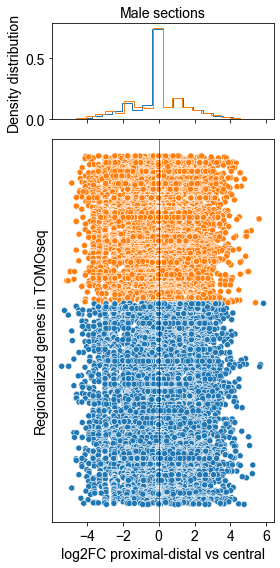

In [44]:
df = df_FC_ann

palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",
}

# Two stacked subplots
fig, (ax_hist, ax_scat) = plt.subplots(
    2, 1, figsize=(4, 8), gridspec_kw={'height_ratios':[1, 4]}, sharex=True
)

# --- Histogram (top) ---
for annot, color in palette.items():
    subset = df.loc[df["Annotation"] == annot, "log2FC A-P vs C"]
    ax_hist.hist(
        subset,
        bins=20,
        histtype='step',  # outline only
        color=color,
        linewidth=1, density=True
    )

ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.tick_params(axis='y', labelsize=14)
ax_hist.set_ylabel("Density distribution", fontsize=14)
ax_hist.set_title("Male sections", fontsize=14)

# --- Scatter (bottom) ---
sns.scatterplot(
    data=df,
    x='log2FC A-P vs C',
    y='Gene',
    hue='Annotation',
    palette=palette,
    ax=ax_scat,
    legend=False,  # disables legend
    rasterized=True
)

ax_scat.axvline(x=0, c='black', ls='-', linewidth=0.5)
ax_scat.set_xlabel("log2FC proximal-distal vs central", fontsize=14)
ax_scat.set_ylabel("Regionalized genes in TOMOseq", fontsize=14)
ax_scat.tick_params(axis='both', labelsize=14)
ax_scat.grid(True, which='major', axis='y', ls='--', linewidth=0.25)
ax_scat.set_yticks([])  # optional: hide gene labels


# 8. Final formatting and export
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("log2FC C vs PD individual tss male.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

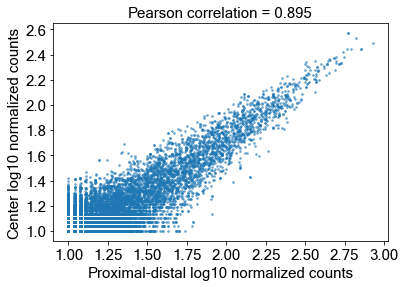

In [50]:
### correlation A-P vs C
data_frame=pd.DataFrame(index=data_normal_C.index)
my_list1=list(data_normal_AP.sum(axis=1))
data_frame['Anterior-Posterior']=np.log10([x+10 for x in my_list1])
my_list2=list(data_normal_C.sum(axis=1))
data_frame['Center']=np.log10([x+10 for x in my_list2])


pearson_corr=pearsonr(data_frame['Anterior-Posterior'], data_frame['Center'])

data_frame.plot(x='Anterior-Posterior', y='Center', kind='scatter', alpha = 0.5, style="o", s=3);
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=15)
plt.ylabel('Center'+' log10 normalized counts', fontsize=15)
plt.show()

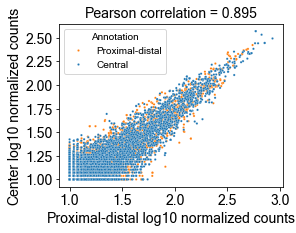

In [51]:
data_frame_ann=pd.concat([data_frame, list_ann2], axis=1)
data_frame_ann=data_frame_ann.sort_values('Annotation', ascending=False)
palette = {
    "Central": "tab:blue",
    "Proximal-distal": "tab:orange",

}

plt.figure(figsize=(4,3))
ax = sns.scatterplot(data=data_frame_ann, x='Anterior-Posterior', y='Center', hue='Annotation', palette=palette,s=5, rasterized=True)
plt.title('Pearson correlation = ' + str(round(pearson_corr[0],3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Proximal-distal'+' log10 normalized counts', fontsize=14)
plt.ylabel('Center'+' log10 normalized counts', fontsize=14)
# 8. Final formatting and export
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "Microsoft Sans Serif"
plt.savefig("correlation C vs PD indivual tss male.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
